<p align="center">
  <img src="https://raw.githubusercontent.com/ahmedfgad/NumPyCNN/master/images/alphabets.png" width="650">
</p>


## About Dataset

### Context
For recognising handwritten forms, the very first step was to gather data in a considerable amount for training. Which I struggled to collect for weeks.

### Content
The dataset contains 26 folders (A-Z) containing handwritten images in size 2828 pixels, each alphabet in the image is centre fitted to 2020 pixel box.

Each image is stored as Gray-level

Kernel CSVToImages contains script to convert .CSV file to actual images in .png format in structured folder.

Note: Might contain some noisy image as well

### Acknowledgements
The images are taken from NIST(https://www.nist.gov/srd/nist-special-database-19) and NMIST large dataset and few other sources which were then formatted as mentioned above.


## Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import os
import tensorflow as tf
import warnings

from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score,r2_score,classification_report

from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D
from keras.optimizers import SGD, Adam
from keras.callbacks import ReduceLROnPlateau, EarlyStopping
from keras.utils import to_categorical, np_utils
from keras import backend as K
from keras.preprocessing.image import ImageDataGenerator


warnings.filterwarnings('ignore')
sns.set()


## Read dataset with pandas (python)

In [2]:
df = pd.read_csv('/kaggle/input/az-handwritten-alphabets-in-csv-format/A_Z Handwritten Data.csv').astype('float32')
df.head()

,0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,...,0.639,0.640,0.641,0.642,0.643,0.644,0.645,0.646,0.647,0.648
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [3]:
my_frame = pd.DataFrame(df)
my_frame.head()

,0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,...,0.639,0.640,0.641,0.642,0.643,0.644,0.645,0.646,0.647,0.648
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
my_frame.shape

(372450, 785)

In [5]:
my_frame.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 372450 entries, 0 to 372449
Columns: 785 entries, 0 to 0.648
dtypes: float32(785)
memory usage: 1.1 GB


In [6]:
my_frame.describe()

,0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,...,0.639,0.640,0.641,0.642,0.643,0.644,0.645,0.646,0.647,0.648
count,372450.000000,372450.0,372450.0,372450.0,372450.0,372450.0,372450.0,372450.0,372450.0,372450.0,...,372450.000000,372450.000000,372450.000000,372450.000000,372450.000000,372450.000000,372450.000000,372450.000000,372450.000000,372450.000000
mean,13.523490,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.001616,0.001592,0.001117,0.000929,0.000685,0.000596,0.000618,0.000690,0.000239,0.000011
std,6.736685,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.490786,0.517295,0.421331,0.419179,0.385566,0.319819,0.208941,0.335227,0.134852,0.006554
min,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,10.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,14.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,18.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,25.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,252.000000,226.000000,229.000000,228.000000,235.000000,194.000000,103.000000,198.000000,82.000000,4.000000


### We notice that some columns only conatain 0
#### But we **should not remove zero-only columns** because they represent **background pixels with fixed spatial positions**, which are essential to preserve the **28×28 image structure**.
#### Removing them breaks the spatial layout, making reshaping invalid and **confusing CNNs that rely on spatial relationships**.


In [7]:
my_frame.isnull().sum()

0        0
0.1      0
0.2      0
0.3      0
0.4      0
        ..
0.644    0
0.645    0
0.646    0
0.647    0
0.648    0
Length: 785, dtype: int64

In [8]:
my_frame.isnull().sum().sum()

0

## Split x and y column from dataset

In [9]:
x = my_frame.drop('0', axis = 1)
y = my_frame['0']

In [10]:
y.value_counts()

14.0    57825
18.0    48419
20.0    29008
2.0     23409
19.0    22495
15.0    19341
13.0    19010
0.0     13869
12.0    12336
11.0    11586
17.0    11566
4.0     11440
24.0    10859
22.0    10784
3.0     10134
1.0      8668
9.0      8493
7.0      7218
23.0     6272
25.0     6076
16.0     5812
6.0      5762
10.0     5603
21.0     4182
5.0      1163
8.0      1120
Name: 0, dtype: int64

## Explore


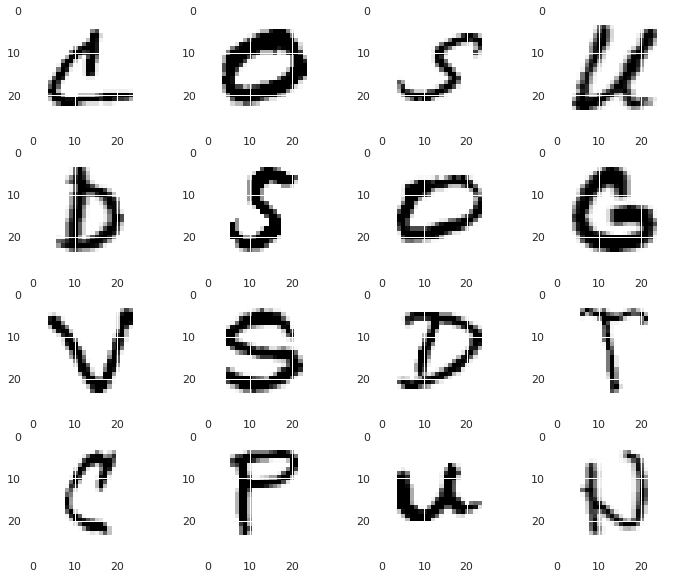

In [11]:
from sklearn.utils import shuffle

X_shuffle = shuffle(x)

plt.figure(figsize = (12,10))
row, colums = 4, 4
for i in range(16):  
    plt.subplot(colums, row, i+1)
    plt.imshow(X_shuffle.iloc[i].values.reshape(28,28),interpolation='nearest', cmap='Greys')
plt.show()

## Reshaping images from dataset

In [12]:
# we are reshaping the train & test image data so that they can be displayed as an image, 
# as initially in the CSV file they were present as 784 columns of pixel data. So we convert it to 28×28 pixels.

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2)
x_train = np.reshape(x_train.values, (x_train.shape[0], 28, 28))
x_test = np.reshape(x_test.values, (x_test.shape[0], 28, 28))

print('Train Data Shape:', x_train.shape)
print('Test Data Shape:', x_test.shape)

Train Data Shape: (297960, 28, 28)
Test Data Shape: (74490, 28, 28)


## Plotting number of alphabets from dataset

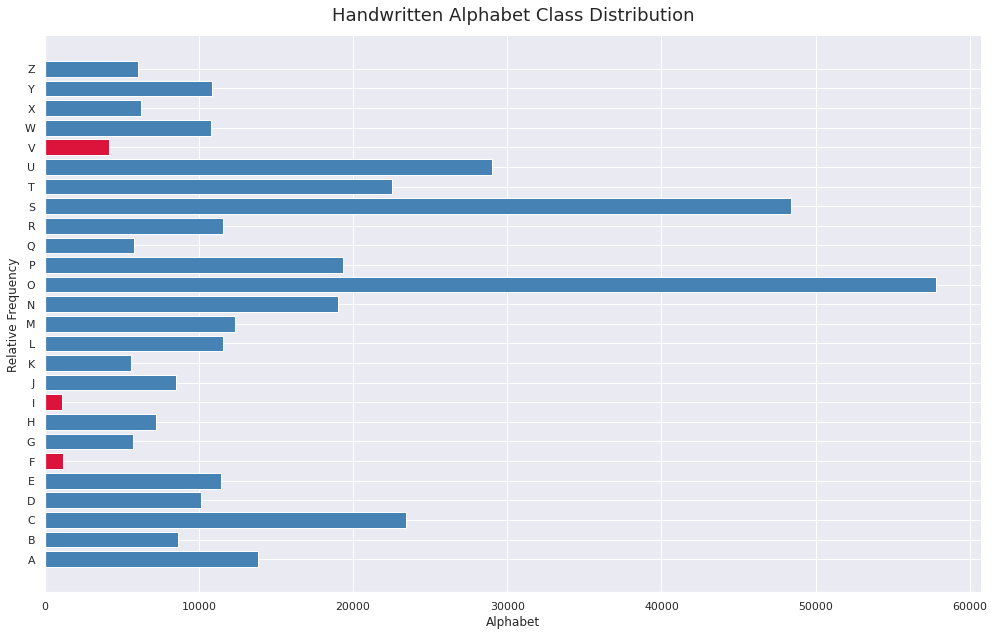

In [13]:

# Map labels to alphabets
df['label'] = df['0'].map({i: chr(65+i) for i in range(26)})

# Count labels
label_size = df['label'].value_counts().sort_index()

# Identify low-frequency labels (bottom 10%)
threshold = np.percentile(label_size.values, 10)
colors = ['crimson' if v <= threshold else 'steelblue' for v in label_size.values]

# Plot
plt.figure(figsize=(14, 9))
plt.barh(label_size.index, label_size.values, color=colors)

plt.title("Handwritten Alphabet Class Distribution", fontsize=18, pad=15)
plt.xlabel("Alphabet", fontsize=12)
plt.ylabel("Relative Frequency", fontsize=12)

sns.despine()
plt.tight_layout()
plt.show()


The data isn't balanced

## Reshaping train & test images from dataset to put in Deep Learning Model

In [14]:
# Reshaping the training & test dataset so that it can be put in the model
# Now we reshape the train & test image dataset so that they can be put in the model.
# New shape of train data: (297960, 28, 28, 1)
# New shape of test data: (74490, 28, 28, 1)

x_train = x_train.reshape(x_train.shape[0], x_train.shape[1], x_train.shape[2], 1)
print("New shape of train data:", x_train.shape)

x_test = x_test.reshape(x_test.shape[0], x_test.shape[1], x_test.shape[2], 1)
print("New shape of test data:", x_test.shape)

New shape of train data: (297960, 28, 28, 1)
New shape of test data: (74490, 28, 28, 1)


### Creating dictionary of alphabets with indexes¶


In [15]:
word_dict = {
    0:'A',1:'B',2:'C',3:'D',4:'E',5:'F',6:'G',7:'H',8:'I',9:'J',10:'K',11:'L',12:'M',13:'N',14:'O',15:'P',16:'Q',17:'R',18:'S',19:'T',20:'U',21:'V',22:'W',23:'X', 24:'Y',25:'Z'
}

### No Data Augmentation is needed

In [16]:

# datagen = ImageDataGenerator(
#     rotation_range=10,
#     width_shift_range=0.1,
#     height_shift_range=0.1,
#     zoom_range=0.1
# )


In [17]:
# VAL_SIZE = len(x_train) // 4

# aug_images = []
# aug_labels = []
# current_size = 0

# for x_batch, y_batch in datagen.flow(
#         x_train, y_train, batch_size=32, shuffle=False):

#     aug_images.append(x_batch)
#     aug_labels.append(y_batch)

#     current_size += len(x_batch)
#     if current_size >= VAL_SIZE:
#         break

# x_val = np.concatenate(aug_images)[:VAL_SIZE]
# y_val = np.concatenate(aug_labels)[:VAL_SIZE]


In [18]:
# x_val  = x_val / 255.0
# plt.figure(figsize=(8, 8))

# for i in range(16):
#     plt.subplot(4, 4, i + 1)
#     plt.imshow(x_val[i].reshape(28, 28), cmap='gray')
#     plt.title("Augmented")
#     plt.axis('off')

# plt.tight_layout()
# plt.show()


## Label encoding and scalling

In [19]:
# Here we convert the single float values to categorical values. 

# y_val = to_categorical(y_val, num_classes=26)
# print("New shape of val labels:", y_val.shape)

categorical_train = to_categorical(y_train, num_classes = 26, dtype = 'int')
print("New shape of train labels:", categorical_train.shape)

categorical_test = to_categorical(y_test, num_classes = 26, dtype = 'int')
print("New shape of test labels:", categorical_test.shape)

New shape of train labels: (297960, 26)
New shape of test labels: (74490, 26)


In [20]:
# scaling
x_train = x_train / 255.0
x_test  = x_test / 255.0


Data after scaleing


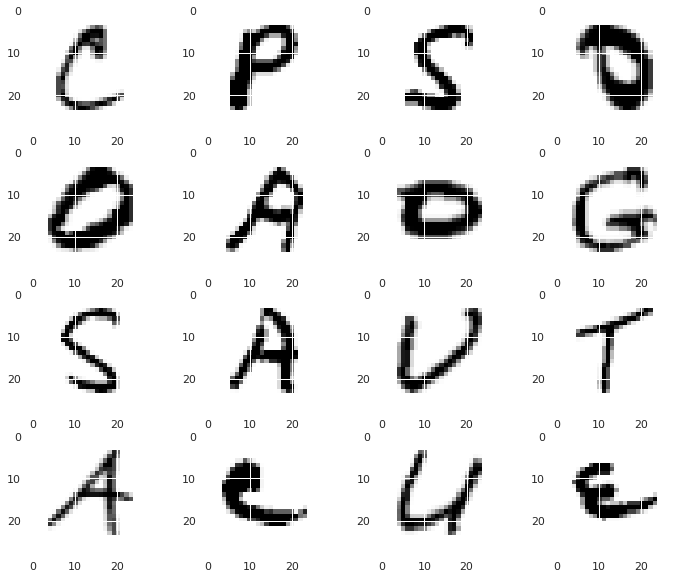

In [22]:
print("Data after scaleing")
X_shuffle = shuffle(x_train)

plt.figure(figsize = (12,10))
row, colums = 4, 4
for i in range(16):  
    plt.subplot(colums, row, i+1)
    plt.imshow(X_shuffle[i].reshape(28,28),interpolation='nearest', cmap='Greys')
plt.show()

In [23]:
print(x_train[x_train!=0])
# scaled!

[0.20392157 0.69411767 0.93333334 ... 0.03529412 0.6156863  0.29411766]


## Implementation of CNN Model

<img src="/kaggle/input/rules-of-modeling/bdf9563d-5823-45bf-b7d8-155079c541c7.jpg">

#### We need to answer these questions before continueing
### choosing the Hyperparameters

### 1. Architecture-related Hyperparameters
These hyperparameters define the structure of the neural network and control how information flows through it.

- Number of layers  
- Number of neurons per layer  
- Type of layers (e.g., dense, convolutional, recurrent)  
- Connection type (e.g., fully connected, sparse connections)  
- Skip connections (e.g., residual connections)  
- Recurrent connections (e.g., LSTM, GRU)  
- Type of activation function (e.g., ReLU, sigmoid, tanh, Leaky ReLU, ELU)  
- Dropout layer positions in the network  
- Dropout rate  
- Batch normalization positions in the network  

---

### 2. Training and Evaluation-related Hyperparameters
These hyperparameters control how the model is trained and how its performance is evaluated.

- Number of epochs  
- Training / validation / test split ratio  
- Loss function (e.g., cross-entropy, mean squared error)  
- Evaluation metrics (e.g., accuracy, precision, recall, F1-score)  
- Cross-validation settings (e.g., k-fold cross-validation)  
- Learning rate  
- Optimizer choice (e.g., SGD, Adam, RMSprop, Adagrad)  
- Mini-batch size  


In [24]:
# ================================
# Hyperparameters Configuration
# ================================

# Architecture-related hyperparameters
NUM_CONV_LAYERS = 3
NUM_DENSE_LAYERS = 3  # including output layer

CONV_FILTERS = [32, 64, 128]
KERNEL_SIZES = [(3, 3), (3, 3), (3, 3)]
POOL_SIZE = (2, 2)

DENSE_NEURONS = [64, 128]
OUTPUT_CLASSES = 26

LAYER_TYPES = ["Conv2D", "MaxPooling2D", "Flatten", "Dense"]

CONNECTION_TYPE = "Fully Connected"
SKIP_CONNECTIONS = None        # Not used
RECURRENT_LAYERS = None        # Not used (no LSTM/GRU)

ACTIVATION_CONV = "relu"
ACTIVATION_DENSE = "relu"
ACTIVATION_OUTPUT = "softmax"

DROPOUT_POSITIONS = None    
DROPOUT_RATE = .25             
BATCH_NORM_POSITIONS = None    # Batch Normalization not used


# Training and evaluation-related hyperparameters
EPOCHS = 25
TRAIN_TEST_SPLIT = 0.2         # 80% train, 20% test
LOSS_FUNCTION = "categorical_crossentropy"
EVALUATION_METRICS = ["accuracy"]

CROSS_VALIDATION = None        # No k-fold cross validation
LEARNING_RATE = None           # Default Adam learning rate
OPTIMIZER = "Adam"
BATCH_SIZE = 32                # Default batch size


In [25]:

my_model = Sequential()

my_model.add(Conv2D(filters = 32, kernel_size = (3, 3), activation = 'relu', input_shape = (28, 28, 1)))
my_model.add(Dropout(0.25))

my_model.add(MaxPooling2D(pool_size = (2, 2), strides = 2))

my_model.add(Conv2D(filters = 64, kernel_size = (3, 3), activation = 'relu', padding = 'same'))
my_model.add(Dropout(0.25))

my_model.add(MaxPooling2D(pool_size = (2, 2), strides = 2))

my_model.add(Conv2D(filters = 128, kernel_size = (3, 3), activation = 'relu', padding = 'valid'))
my_model.add(Dropout(0.25))
my_model.add(MaxPooling2D(pool_size = (2, 2), strides = 2))

my_model.add(Flatten())

my_model.add(Dense(64, activation = "relu"))
my_model.add(Dense(128, activation = "relu"))

my_model.add(Dense(26, activation = "softmax"))

In [26]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)
lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    verbose=1
)


In [ ]:
# Now we are getting the model summary that tells us what were the different layers defined in the model &

my_model.summary()


## Compiling the Model

In [28]:
# 1): Here we are compiling the model, where we define the optimizing function & the loss function to be used for fitting.
# 2): The optimizing function used is Adam, that is a combination of RMSprop & Adagram optimizing algorithms.
# 3): The dataset is very large so we are training for only a single epoch, 
#     however, as required we can even train it for multiple epochs 
#     (which is recommended for character recognition for better accuracy).

my_model.compile(optimizer = 'adam', loss = 'categorical_crossentropy', metrics = ['accuracy'])
history= my_model.fit(
    x_train,
    categorical_train,

    epochs=EPOCHS,
    validation_data=(x_test, categorical_test),
    callbacks=[early_stop, lr_scheduler]
)


Epoch 1/25
9312/9312 [==============================] - 40s 4ms/step - loss: 0.3156 - accuracy: 0.9095 - val_loss: 0.0837 - val_accuracy: 0.9792
Epoch 2/25
9312/9312 [==============================] - 32s 3ms/step - loss: 0.0734 - accuracy: 0.9789 - val_loss: 0.0740 - val_accuracy: 0.9868
Epoch 3/25
9312/9312 [==============================] - 32s 3ms/step - loss: 0.0596 - accuracy: 0.9828 - val_loss: 0.0618 - val_accuracy: 0.9840
Epoch 4/25
9312/9312 [==============================] - 32s 3ms/step - loss: 0.0542 - accuracy: 0.9846 - val_loss: 0.0544 - val_accuracy: 0.9885
Epoch 5/25
9312/9312 [==============================] - 32s 3ms/step - loss: 0.0489 - accuracy: 0.9862 - val_loss: 0.0468 - val_accuracy: 0.9892
Epoch 6/25
9312/9312 [==============================] - 32s 3ms/step - loss: 0.0461 - accuracy: 0.9869 - val_loss: 0.0424 - val_accuracy: 0.9886
Epoch 7/25
9312/9312 [==============================] - 32s 3ms/step - loss: 0.0462 - accuracy: 0.9867 - val_loss: 0.0412 - val_ac

## Plot the acc and loss 

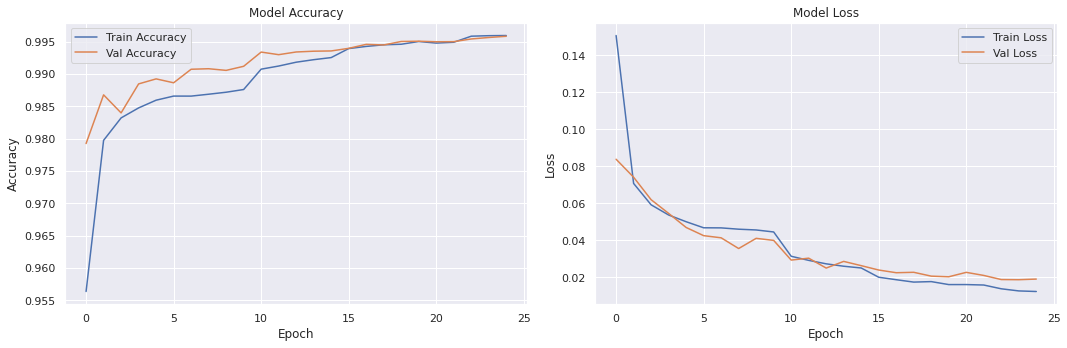

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Accuracy
axes[0].plot(history.history['accuracy'], label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

# Loss
axes[1].plot(history.history['loss'], label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Val Loss')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [30]:
# also we save the model using model.save() function.
my_model.save(r'best_model.h5')

## Find accuracy, losses of Model

In [31]:
print("Training Accuracy:", round(history.history['accuracy'][-1] * 100, 3), "%")
print("Validation Accuracy:", round(history.history['val_accuracy'][-1] * 100, 3), "%")
print("Training Loss:", round(history.history['loss'][-1], 4))
print("Validation Loss:", round(history.history['val_loss'][-1], 4))


Training Accuracy: 99.596 %
Validation Accuracy: 99.584 %
Training Loss: 0.0122
Validation Loss: 0.0189


## Finally, make predictions on the test data

In [32]:
y_pred_prob = my_model.predict(x_test)
ypred = np.argmax(y_pred_prob, axis=1)

print(classification_report(y_test,ypred))


              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      2764
         1.0       0.99      1.00      0.99      1709
         2.0       1.00      1.00      1.00      4632
         3.0       0.98      0.98      0.98      2042
         4.0       1.00      1.00      1.00      2222
         5.0       0.99      0.99      0.99       228
         6.0       1.00      0.99      0.99      1180
         7.0       0.99      0.99      0.99      1416
         8.0       1.00      1.00      1.00       237
         9.0       0.99      0.99      0.99      1725
        10.0       0.99      0.99      0.99      1105
        11.0       1.00      0.99      0.99      2398
        12.0       1.00      1.00      1.00      2450
        13.0       1.00      1.00      1.00      3750
        14.0       1.00      1.00      1.00     11472
        15.0       1.00      1.00      1.00      3924
        16.0       0.99      1.00      0.99      1201
        17.0       0.99    

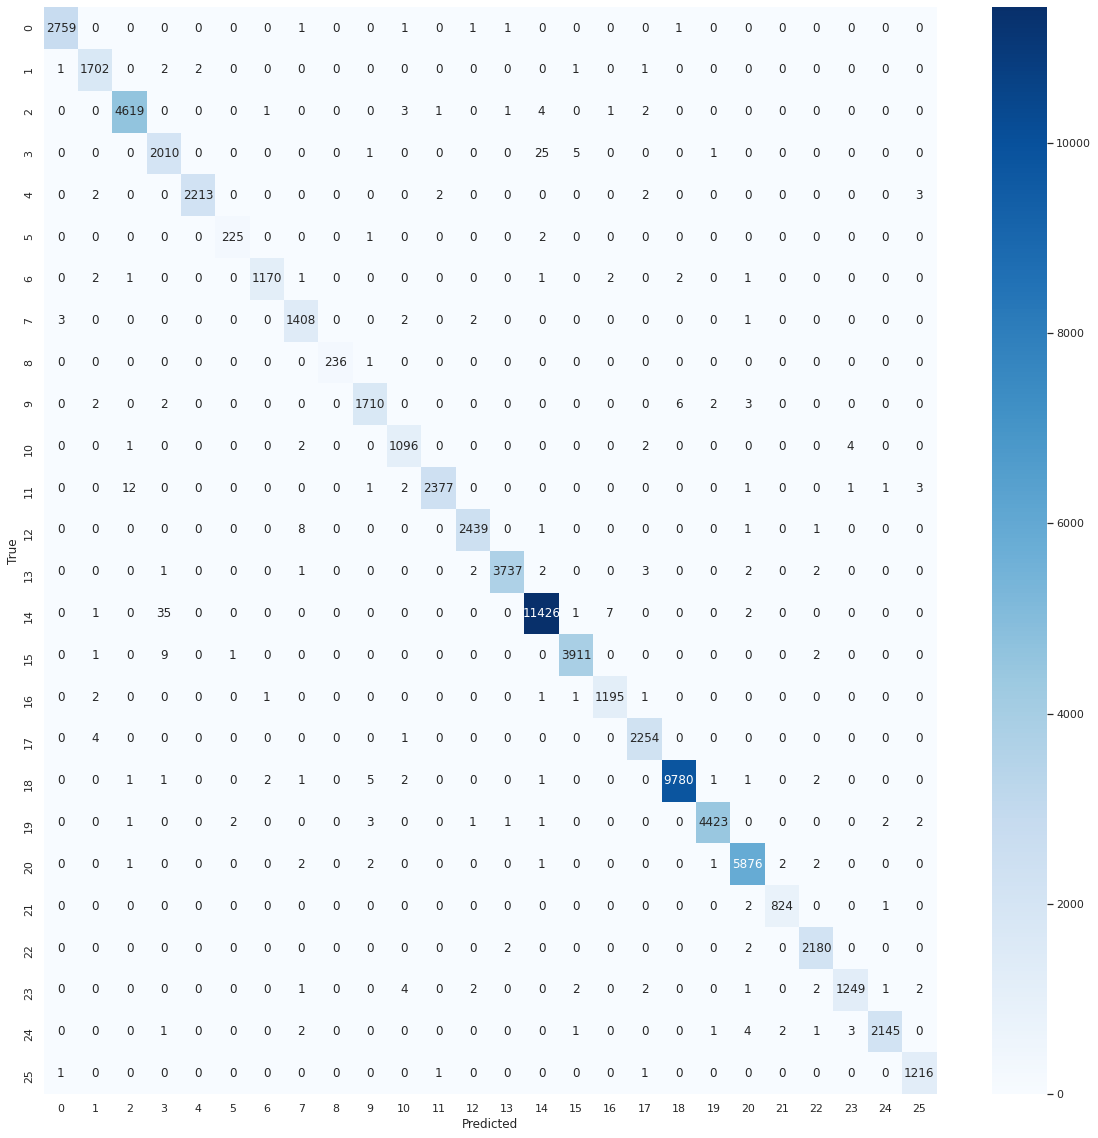

In [33]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, ypred)
plt.figure(figsize=(20,20))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

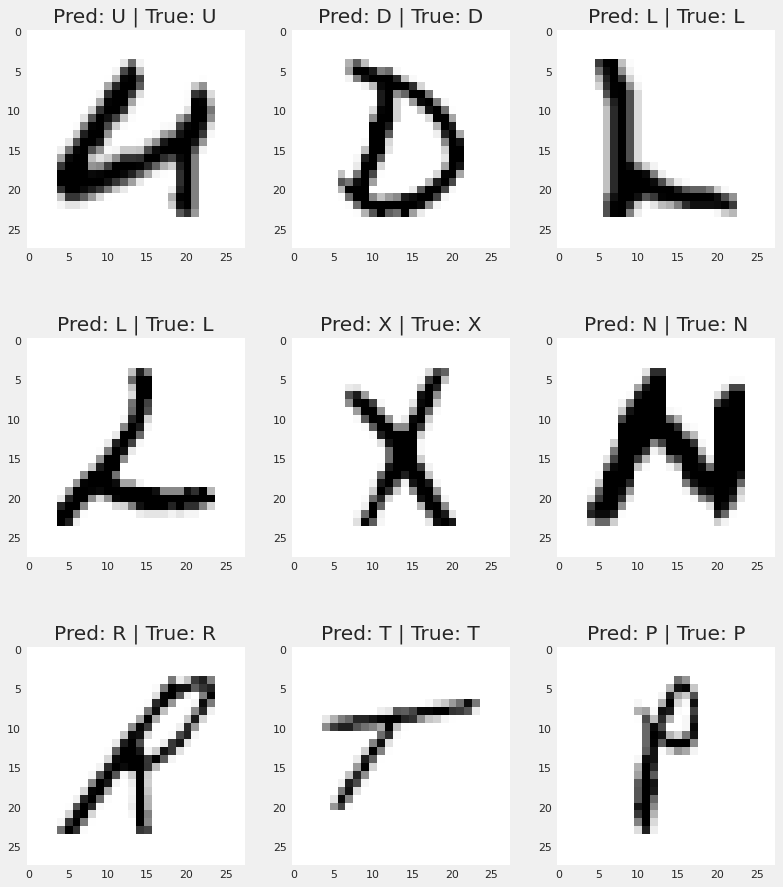

In [34]:
# Here we are creating 9 subplots of (3,3) shape & visualize some of the test dataset alphabets along with their predictions, 
# that are made using the model.predict() function for text recognition.

plt.style.use('fivethirtyeight')

fig, axes = plt.subplots(3, 3, figsize = (12, 15))
axes = axes.flatten()

for i, ax in enumerate(axes):
    img = np.reshape(x_test[i], (28, 28))
    ax.imshow(img, cmap = 'Greys')
    
    true = word_dict[y_test.iloc[i]]
    pred = word_dict[ypred[i]]
    ax.set_title(f"Pred: {pred} | True: {true}")
    # ax.set_title("Prediction: " + pred, fontsize = 20, fontweight = 'bold', color = 'red')
    ax.grid()

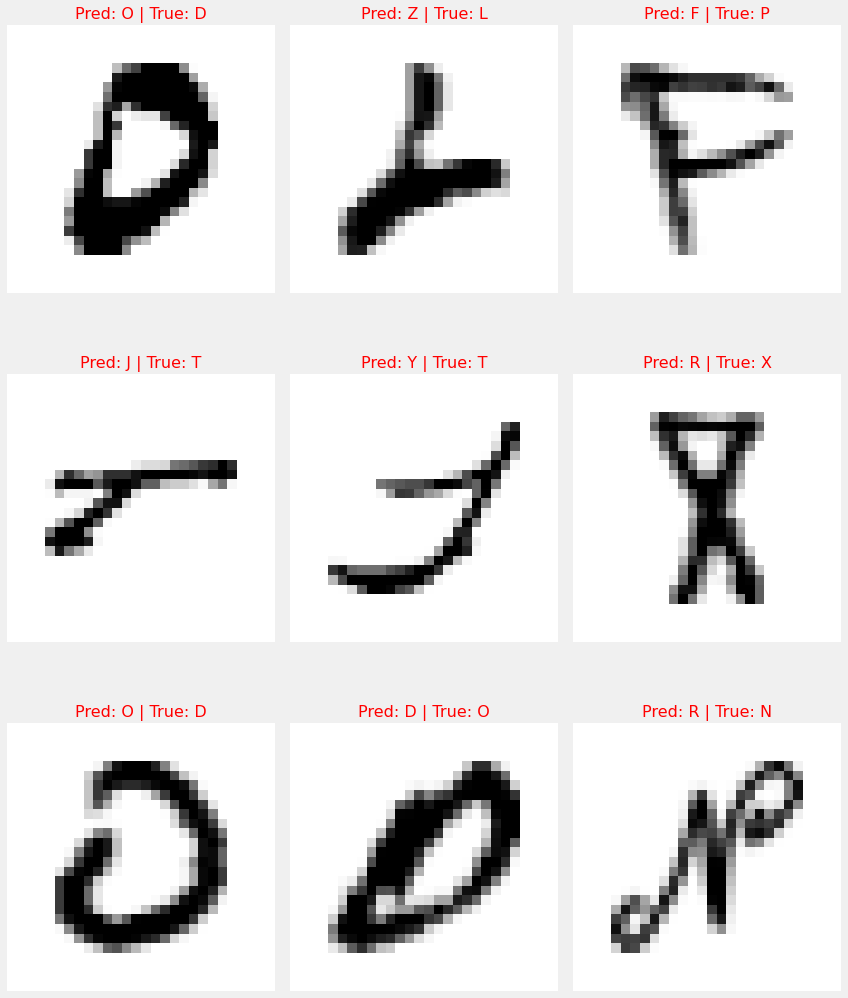

In [35]:
# Find wrong predictions
wrong_idx = np.where(ypred != y_test.values)[0]

plt.style.use('fivethirtyeight')

fig, axes = plt.subplots(3, 3, figsize=(12, 15))
axes = axes.flatten()

for ax, idx in zip(axes, wrong_idx[:9]):
    img = x_test[idx].reshape(28, 28)
    ax.imshow(img, cmap='Greys')

    true_label = word_dict[y_test.iloc[idx]]
    pred_label = word_dict[ypred[idx]]

    ax.set_title(
        f"Pred: {pred_label} | True: {true_label}",
        fontsize=16,
        color='red'
    )
    ax.axis('off')  

plt.tight_layout()
plt.show()


#### This is a great model but it gets 99% acc on train and test
#### We need another test

# Try on another dataset 

In [95]:
# Load and Filter ONLY Uppercase A–Z because dataset also contains numbers which the model wasn't trained on

DATASET_ROOT = "/kaggle/input/english-handwritten-characters-dataset"
CSV_PATH = os.path.join(DATASET_ROOT, "/kaggle/input/english-handwritten-characters-dataset/english.csv")  # عدّل لو الاسم مختلف

df = pd.read_csv(CSV_PATH)

df = df[df["label"].astype(str).str.match(r"^[A-Z]$")].reset_index(drop=True)

print("Samples after filtering:", len(df))
print(df.head())

label_to_idx = {chr(i+65): i for i in range(26)}

X_test = []
y_test = []

for _, row in df.iterrows():
    img_path = os.path.join(DATASET_ROOT, row["image"])
    label = label_to_idx[row["label"]]

    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        continue

    img = cv2.resize(img, (28, 28))
    img = img / 255.0
    img = img.reshape(28, 28, 1)

    X_test.append(img)
    y_test.append(label)

X_test = np.array(X_test, dtype="float32")
y_test = np.array(y_test)

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)


Samples after filtering: 1430
                image label
0  Img/img011-001.png     A
1  Img/img011-002.png     A
2  Img/img011-003.png     A
3  Img/img011-004.png     A
4  Img/img011-005.png     A
X_test shape: (1430, 28, 28, 1)
y_test shape: (1430,)



Test Accuracy (Uppercase only): 15.03%

              precision    recall  f1-score   support

           A       0.00      0.00      0.00        55
           B       0.05      0.11      0.07        55
           C       0.09      0.11      0.10        55
           D       0.07      0.16      0.10        55
           E       0.13      0.22      0.16        55
           F       0.00      0.00      0.00        55
           G       0.17      0.33      0.22        55
           H       0.04      0.04      0.04        55
           I       0.09      0.24      0.14        55
           J       0.00      0.00      0.00        55
           K       0.33      0.04      0.07        55
           L       0.16      0.07      0.10        55
           M       0.00      0.00      0.00        55
           N       0.00      0.00      0.00        55
           O       0.26      0.20      0.22        55
           P       0.16      0.40      0.23        55
           Q       0.11      0.15      0

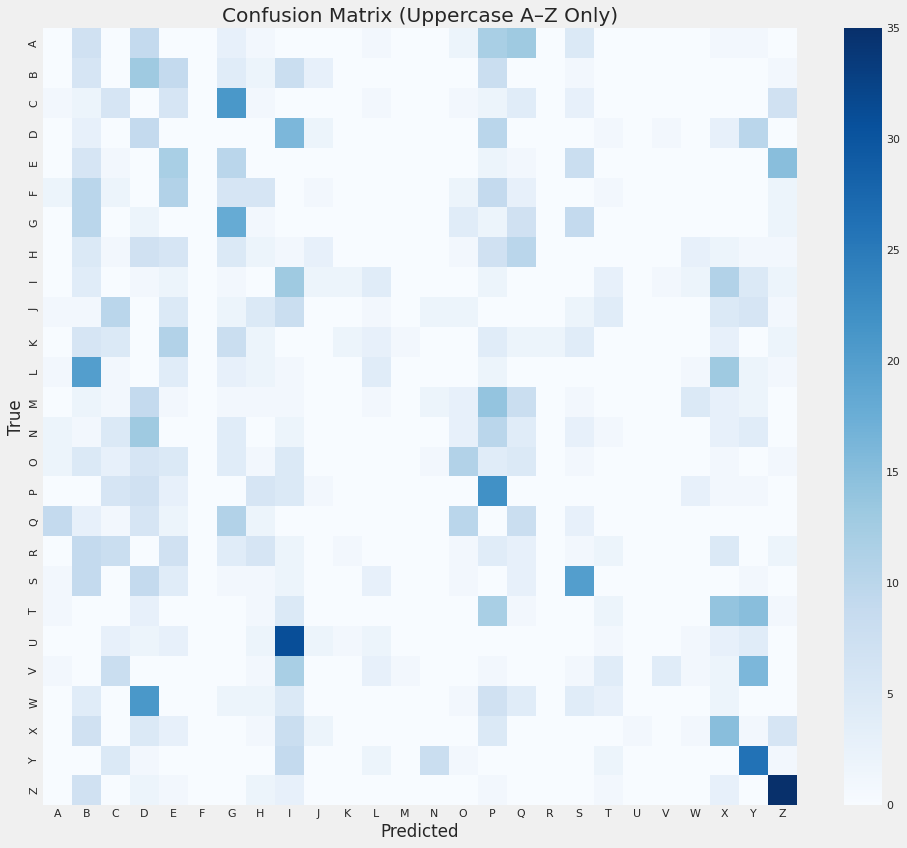

In [96]:
# Make some predictions 
y_pred_prob = my_model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_prob, axis=1)

# Accuracy 
acc = accuracy_score(y_test, y_pred)
print(f"\nTest Accuracy (Uppercase only): {acc*100:.2f}%\n")

#  Classification Report
print(classification_report(
    y_test,
    y_pred,
    target_names=[chr(i+65) for i in range(26)],
    zero_division=0
))

#  Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(14, 12))
sns.heatmap(
    cm,
    cmap="Blues",
    xticklabels=[chr(i+65) for i in range(26)],
    yticklabels=[chr(i+65) for i in range(26)],
    fmt="d"
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (Uppercase A–Z Only)")
plt.tight_layout()
plt.show()


### results are horrible 

In [97]:
# We need to apply the same preprocessing for this dataset
def preprocess_image(img_path):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None

    # Invert if background is white
    if np.mean(img) > 127:
        img = cv2.bitwise_not(img)

    #  Threshold (clean background)
    _, img = cv2.threshold(img, 0, 255,
                            cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    #  Resize
    img = cv2.resize(img, (28, 28))

    #  Normalize
    img = img.astype("float32") / 255.0

    #  Reshape
    img = img.reshape(28, 28, 1)

    return img


In [98]:
X_test = []
y_test = []

for _, row in df.iterrows():
    img_path = os.path.join(DATASET_ROOT, row["image"])
    label = label_to_idx[row["label"]]

    img = preprocess_image(img_path)
    if img is None:
        continue

    X_test.append(img)
    y_test.append(label)

X_test = np.array(X_test, dtype="float32")
y_test = np.array(y_test)



Test Accuracy (Uppercase only): 66.36%

              precision    recall  f1-score   support

           A       0.89      0.76      0.82        55
           B       1.00      0.33      0.49        55
           C       0.81      0.87      0.84        55
           D       0.96      0.78      0.86        55
           E       0.57      0.93      0.70        55
           F       1.00      0.07      0.14        55
           G       0.85      0.80      0.82        55
           H       0.42      0.75      0.54        55
           I       1.00      0.09      0.17        55
           J       0.81      0.62      0.70        55
           K       0.78      0.76      0.77        55
           L       0.79      0.75      0.77        55
           M       0.70      0.69      0.70        55
           N       0.88      0.51      0.64        55
           O       0.70      0.87      0.77        55
           P       0.52      0.98      0.68        55
           Q       0.72      0.60      0

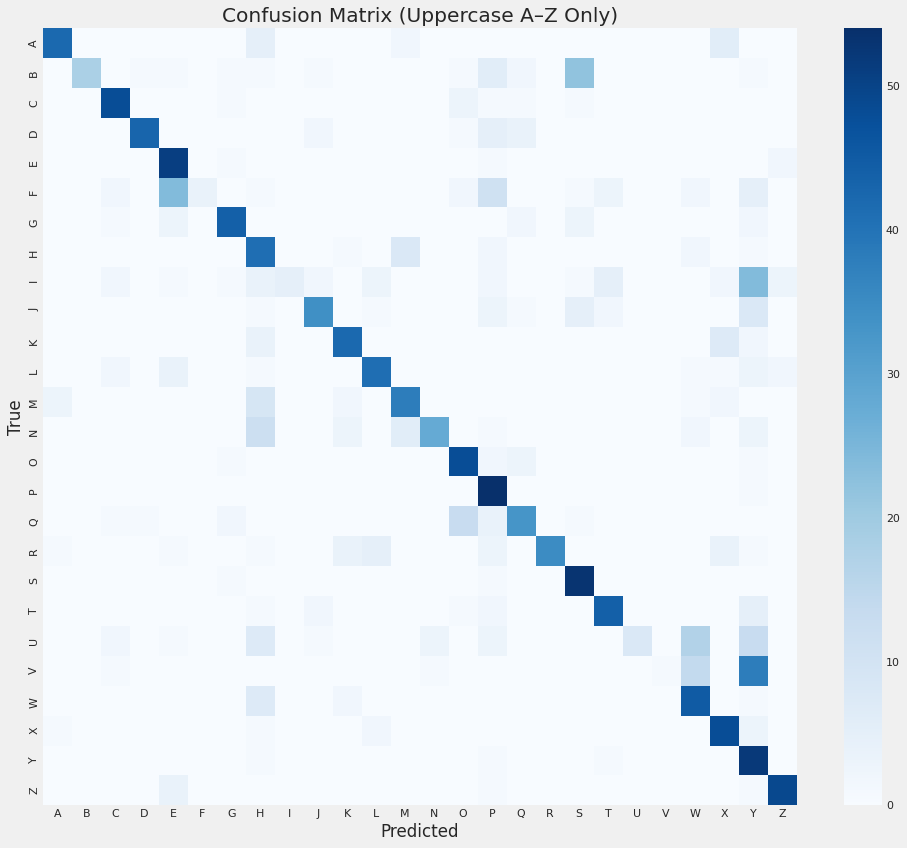

Wrong predictions: 481


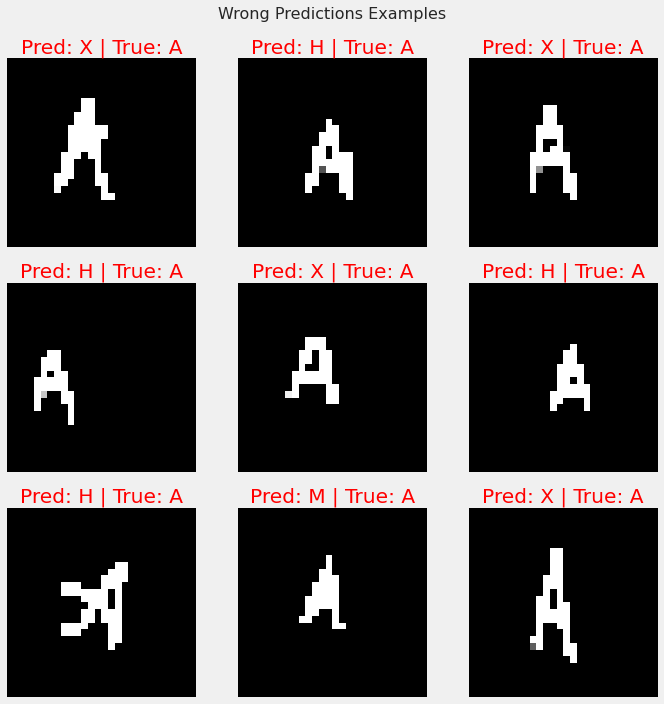

In [99]:
# Make some predictions 
y_pred_prob = my_model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_prob, axis=1)

# Accuracy 
acc = accuracy_score(y_test, y_pred)
print(f"\nTest Accuracy (Uppercase only): {acc*100:.2f}%\n")

#  Classification Report
print(classification_report(
    y_test,
    y_pred,
    target_names=[chr(i+65) for i in range(26)],
    zero_division=0
))

#  Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(14, 12))
sns.heatmap(
    cm,
    cmap="Blues",
    xticklabels=[chr(i+65) for i in range(26)],
    yticklabels=[chr(i+65) for i in range(26)],
    fmt="d"
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (Uppercase A–Z Only)")
plt.tight_layout()
plt.show()

# Show Wrong Predictions 
wrong_idx = np.where(y_pred != y_test)[0]
print("Wrong predictions:", len(wrong_idx))

if len(wrong_idx) > 0:
    plt.figure(figsize=(10, 10))
    for i, idx in enumerate(wrong_idx[:9]):
        plt.subplot(3, 3, i + 1)
        plt.imshow(X_test[idx].reshape(28, 28), cmap="gray")
        plt.title(
            f"Pred: {chr(y_pred[idx]+65)} | True: {chr(y_test[idx]+65)}",
            color="red"
        )
        plt.axis("off")

    plt.suptitle("Wrong Predictions Examples", fontsize=16)
    plt.tight_layout()
    plt.show()
else:
    print("🎉 No wrong pred")

### Better but can we improve it?

In [100]:
# let's try to fine tune the model on the new dataset 
# Freeze all layers first
for layer in my_model.layers:
    layer.trainable = False

# Unfreeze last layers
for layer in my_model.layers[-8:]:
    layer.trainable = True
my_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)
y_test_cat = tf.keras.utils.to_categorical(y_test, num_classes=26)


In [109]:

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)
history_ft = my_model.fit(
    X_test,
    y_test_cat,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    shuffle=True,
    callbacks=[early_stop]

)


Epoch 1/20
36/36 [==============================] - 0s 5ms/step - loss: 0.6379 - accuracy: 0.8269 - val_loss: 1.1519 - val_accuracy: 0.5979
Epoch 2/20
36/36 [==============================] - 0s 4ms/step - loss: 0.5520 - accuracy: 0.8488 - val_loss: 1.1516 - val_accuracy: 0.6049
Epoch 3/20
36/36 [==============================] - 0s 4ms/step - loss: 0.5250 - accuracy: 0.8549 - val_loss: 1.1542 - val_accuracy: 0.6084
Epoch 4/20
36/36 [==============================] - 0s 4ms/step - loss: 0.5817 - accuracy: 0.8295 - val_loss: 1.1580 - val_accuracy: 0.5979
Epoch 5/20
36/36 [==============================] - 0s 4ms/step - loss: 0.4900 - accuracy: 0.8514 - val_loss: 1.1767 - val_accuracy: 0.5979
Epoch 6/20
36/36 [==============================] - 0s 4ms/step - loss: 0.5138 - accuracy: 0.8479 - val_loss: 1.1796 - val_accuracy: 0.5979
Epoch 7/20
36/36 [==============================] - 0s 4ms/step - loss: 0.4976 - accuracy: 0.8497 - val_loss: 1.1840 - val_accuracy: 0.5944


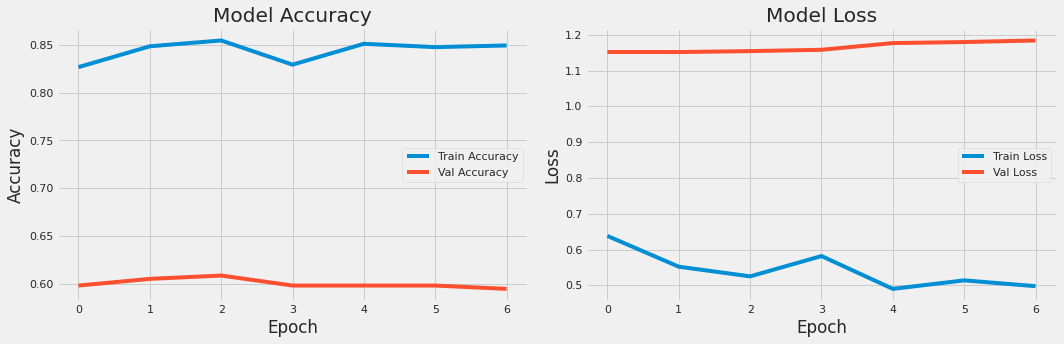

In [110]:
# fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# # Accuracy
# axes[0].plot(history_ft.history['accuracy'], label='Train Accuracy')
# axes[0].plot(history_ft.history['val_accuracy'], label='Val Accuracy')
# axes[0].set_title('Model Accuracy')
# axes[0].set_xlabel('Epoch')
# axes[0].set_ylabel('Accuracy')
# axes[0].legend()
# axes[0].grid(True)

# # Loss
# axes[1].plot(history_ft.history['loss'], label='Train Loss')
# axes[1].plot(history_ft.history['val_loss'], label='Val Loss')
# axes[1].set_title('Model Loss')
# axes[1].set_xlabel('Epoch')
# axes[1].set_ylabel('Loss')
# axes[1].legend()
# axes[1].grid(True)

# plt.tight_layout()
# plt.show()


Test Accuracy (Uppercase only): 83.43%

              precision    recall  f1-score   support

           A       0.89      0.93      0.91        55
           B       0.94      0.84      0.88        55
           C       0.92      0.98      0.95        55
           D       0.91      0.93      0.92        55
           E       0.77      0.98      0.86        55
           F       0.98      0.89      0.93        55
           G       0.98      0.93      0.95        55
           H       0.46      0.87      0.60        55
           I       0.91      0.87      0.89        55
           J       0.83      0.87      0.85        55
           K       0.71      0.89      0.79        55
           L       0.98      0.91      0.94        55
           M       0.75      0.89      0.82        55
           N       0.70      0.73      0.71        55
           O       0.82      0.91      0.86        55
           P       0.96      0.93      0.94        55
           Q       0.92      0.85      0

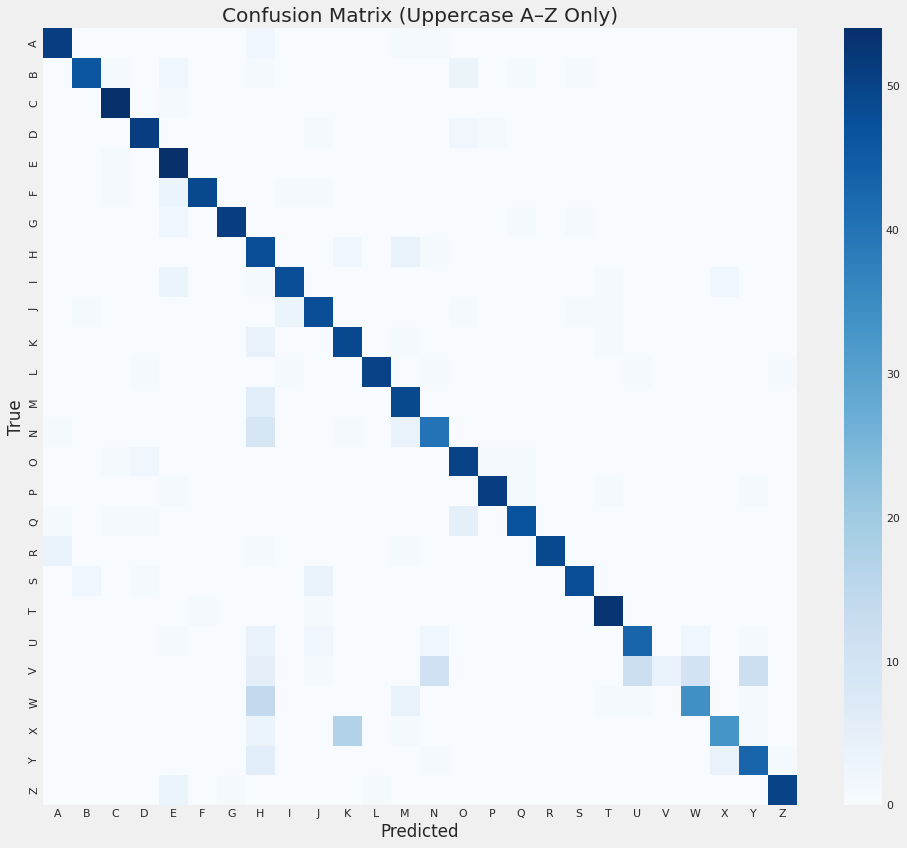

Wrong predictions: 237


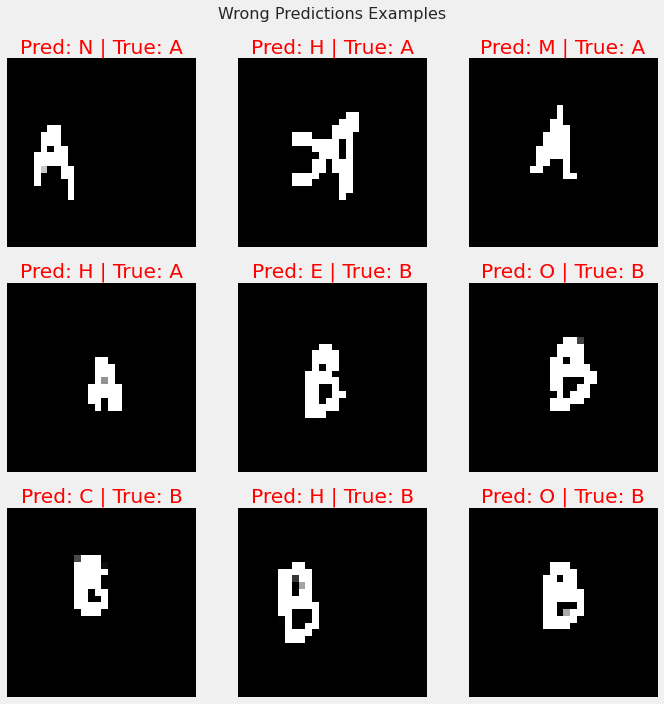

In [111]:
# Make some predictions 
y_pred_prob = my_model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_prob, axis=1)

# Accuracy 
acc = accuracy_score(y_test, y_pred)
print(f"\nTest Accuracy (Uppercase only): {acc*100:.2f}%\n")

#  Classification Report
print(classification_report(
    y_test,
    y_pred,
    target_names=[chr(i+65) for i in range(26)],
    zero_division=0
))

#  Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(14, 12))
sns.heatmap(
    cm,
    cmap="Blues",
    xticklabels=[chr(i+65) for i in range(26)],
    yticklabels=[chr(i+65) for i in range(26)],
    fmt="d"
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (Uppercase A–Z Only)")
plt.tight_layout()
plt.show()

# Show Wrong Predictions 
wrong_idx = np.where(y_pred != y_test)[0]
print("Wrong predictions:", len(wrong_idx))

if len(wrong_idx) > 0:
    plt.figure(figsize=(10, 10))
    for i, idx in enumerate(wrong_idx[:9]):
        plt.subplot(3, 3, i + 1)
        plt.imshow(X_test[idx].reshape(28, 28), cmap="gray")
        plt.title(
            f"Pred: {chr(y_pred[idx]+65)} | True: {chr(y_test[idx]+65)}",
            color="red"
        )
        plt.axis("off")

    plt.suptitle("Wrong Predictions Examples", fontsize=16)
    plt.tight_layout()
    plt.show()
else:
    print("🎉 No wrong pred")

### good job but I think we can do better

#### We can use Data Augmentation + Fine Tuning

In [116]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.model_selection import train_test_split

X_ft_train, X_ft_val, y_ft_train, y_ft_val = train_test_split(
    X_test,
    y_test_cat,
    test_size=0.2,
    random_state=42,
    shuffle=True
)
datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    shear_range=0.1
)

datagen.fit(X_ft_train)

history = my_model.fit(
    datagen.flow(X_ft_train, y_ft_train, batch_size=32),
    epochs=40,
    validation_data=(X_ft_val, y_ft_val),
    shuffle=True,
    callbacks=[early_stop]
)


Epoch 1/40
36/36 [==============================] - 0s 12ms/step - loss: 0.7207 - accuracy: 0.7893 - val_loss: 0.3865 - val_accuracy: 0.8776
Epoch 2/40
36/36 [==============================] - 0s 11ms/step - loss: 0.7166 - accuracy: 0.8182 - val_loss: 0.3833 - val_accuracy: 0.8811
Epoch 3/40
36/36 [==============================] - 0s 11ms/step - loss: 0.7070 - accuracy: 0.7920 - val_loss: 0.3763 - val_accuracy: 0.8811
Epoch 4/40
36/36 [==============================] - 0s 11ms/step - loss: 0.7537 - accuracy: 0.7876 - val_loss: 0.3730 - val_accuracy: 0.8811
Epoch 5/40
36/36 [==============================] - 0s 11ms/step - loss: 0.7068 - accuracy: 0.7788 - val_loss: 0.3723 - val_accuracy: 0.8811
Epoch 6/40
36/36 [==============================] - 0s 11ms/step - loss: 0.6747 - accuracy: 0.8042 - val_loss: 0.3679 - val_accuracy: 0.8811
Epoch 7/40
36/36 [==============================] - 0s 11ms/step - loss: 0.7348 - accuracy: 0.8016 - val_loss: 0.3662 - val_accuracy: 0.8846
Epoch 8/40
36


Test Accuracy (Uppercase only): 91.75%

              precision    recall  f1-score   support

           A       0.93      0.93      0.93        55
           B       0.96      0.91      0.93        55
           C       0.95      0.96      0.95        55
           D       0.88      0.93      0.90        55
           E       0.95      0.95      0.95        55
           F       0.98      0.95      0.96        55
           G       0.96      0.95      0.95        55
           H       0.77      0.78      0.77        55
           I       0.89      0.91      0.90        55
           J       0.94      0.91      0.93        55
           K       0.91      0.95      0.93        55
           L       1.00      0.91      0.95        55
           M       0.83      0.87      0.85        55
           N       0.90      0.85      0.88        55
           O       0.88      0.95      0.91        55
           P       1.00      0.95      0.97        55
           Q       0.93      0.95      0

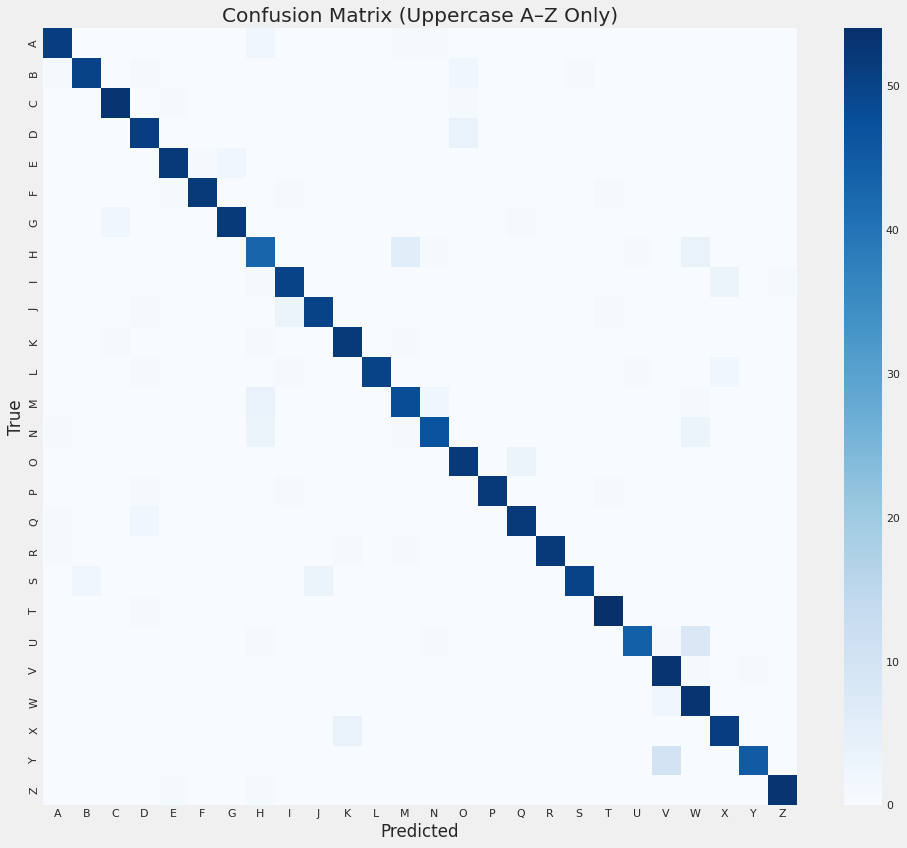

Wrong predictions: 118


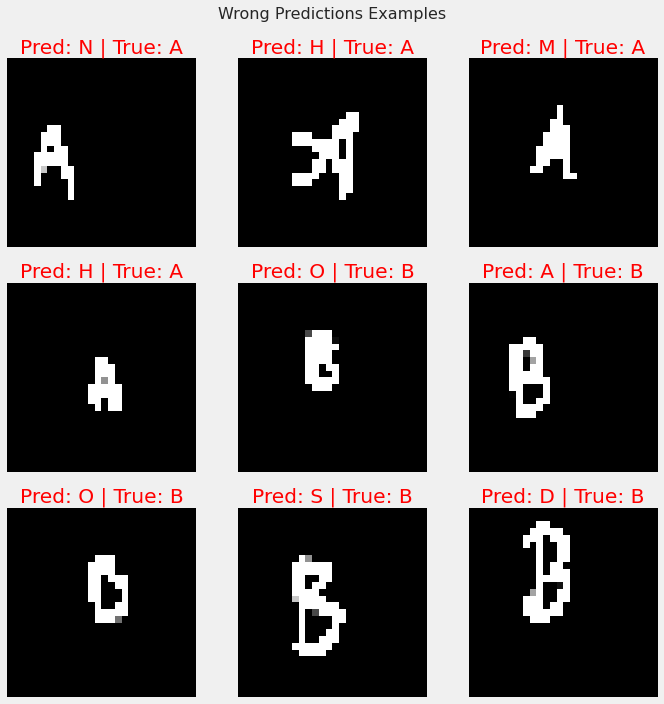

In [117]:
# Make some predictions 
y_pred_prob = my_model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_prob, axis=1)

# Accuracy 
acc = accuracy_score(y_test, y_pred)
print(f"\nTest Accuracy (Uppercase only): {acc*100:.2f}%\n")

#  Classification Report
print(classification_report(
    y_test,
    y_pred,
    target_names=[chr(i+65) for i in range(26)],
    zero_division=0
))

#  Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(14, 12))
sns.heatmap(
    cm,
    cmap="Blues",
    xticklabels=[chr(i+65) for i in range(26)],
    yticklabels=[chr(i+65) for i in range(26)],
    fmt="d"
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (Uppercase A–Z Only)")
plt.tight_layout()
plt.show()

# Show Wrong Predictions 
wrong_idx = np.where(y_pred != y_test)[0]
print("Wrong predictions:", len(wrong_idx))

if len(wrong_idx) > 0:
    plt.figure(figsize=(10, 10))
    for i, idx in enumerate(wrong_idx[:9]):
        plt.subplot(3, 3, i + 1)
        plt.imshow(X_test[idx].reshape(28, 28), cmap="gray")
        plt.title(
            f"Pred: {chr(y_pred[idx]+65)} | True: {chr(y_test[idx]+65)}",
            color="red"
        )
        plt.axis("off")

    plt.suptitle("Wrong Predictions Examples", fontsize=16)
    plt.tight_layout()
    plt.show()
else:
    print("🎉 No wrong pred")

#### I think it's enough 
#### Don't forget to upvote

<p style="text-align:center"><img src="https://media.tenor.com/NUGNhk0Eh64AAAAi/thank-you-thanks.gif"></p>
<br><br>
<p style="text-align:center; font-weight:600; font-size:18px"><em>Thankyou! For viewing this Notebook, Please feel free to provide any feedback!… </em>😄<br>
<img src="https://i.imgur.com/ugj24t1.png" style="width:30%">
</p>

<br><br>
